In [3]:
from utilities import *
from load_data import load_s2_cci, load_modis_ba, load_modis_cci

from tqdm import tqdm
from skimage.measure import label as cc_label
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from rasterio.enums import Resampling

import calendar
import datetime
import pathlib

## Load Data

In [4]:
s2_cci_2016 = load_s2_cci(2016)

In [300]:
s2_cci_2019 = load_s2_cci(2019)

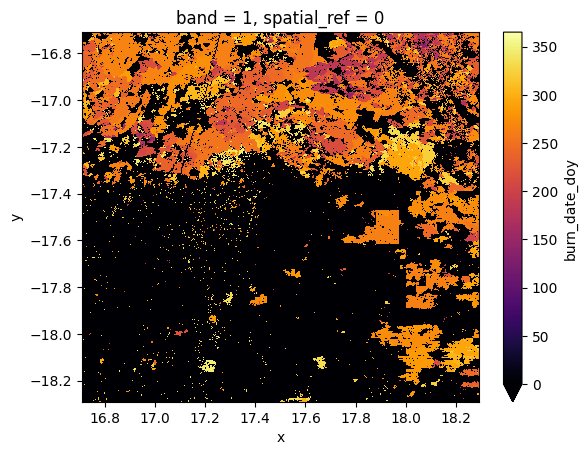

In [223]:
s2_cci_2016.burn_date_doy.plot(cmap="inferno", vmin=0, vmax=365)

## MODIS BA

In [5]:
modis_ba_2016 = load_modis_ba(2016)

In [245]:
modis_ba_2019 = load_modis_ba(2019)

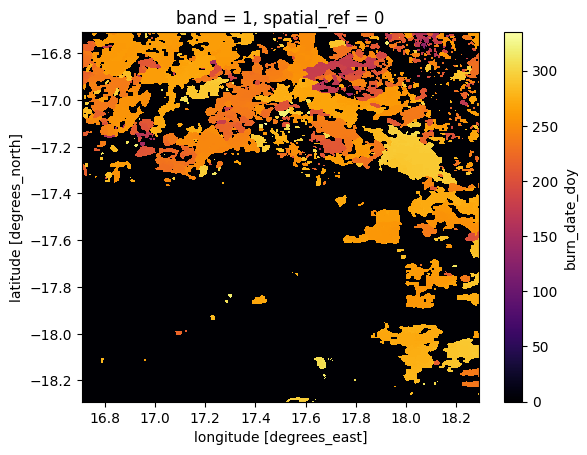

In [50]:
modis_ba_2016.burn_date_doy.plot(cmap="inferno")

## MODIS CCI

In [218]:
modis_cci_2016 = load_modis_cci(2016)

In [246]:
modis_cci_2019 = load_modis_cci(2019)

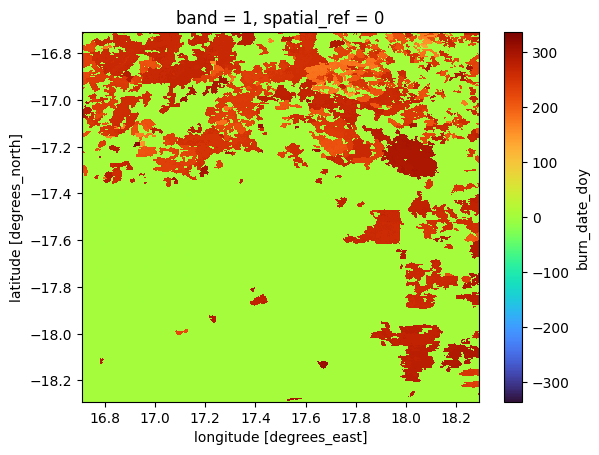

In [49]:
modis_cci_2016.burn_date_doy.plot(cmap="turbo")

/var/folders/qp/6s799t797f17j9t6jsv41rpr0000gn/T/ipykernel_48541/3480784892.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 1])


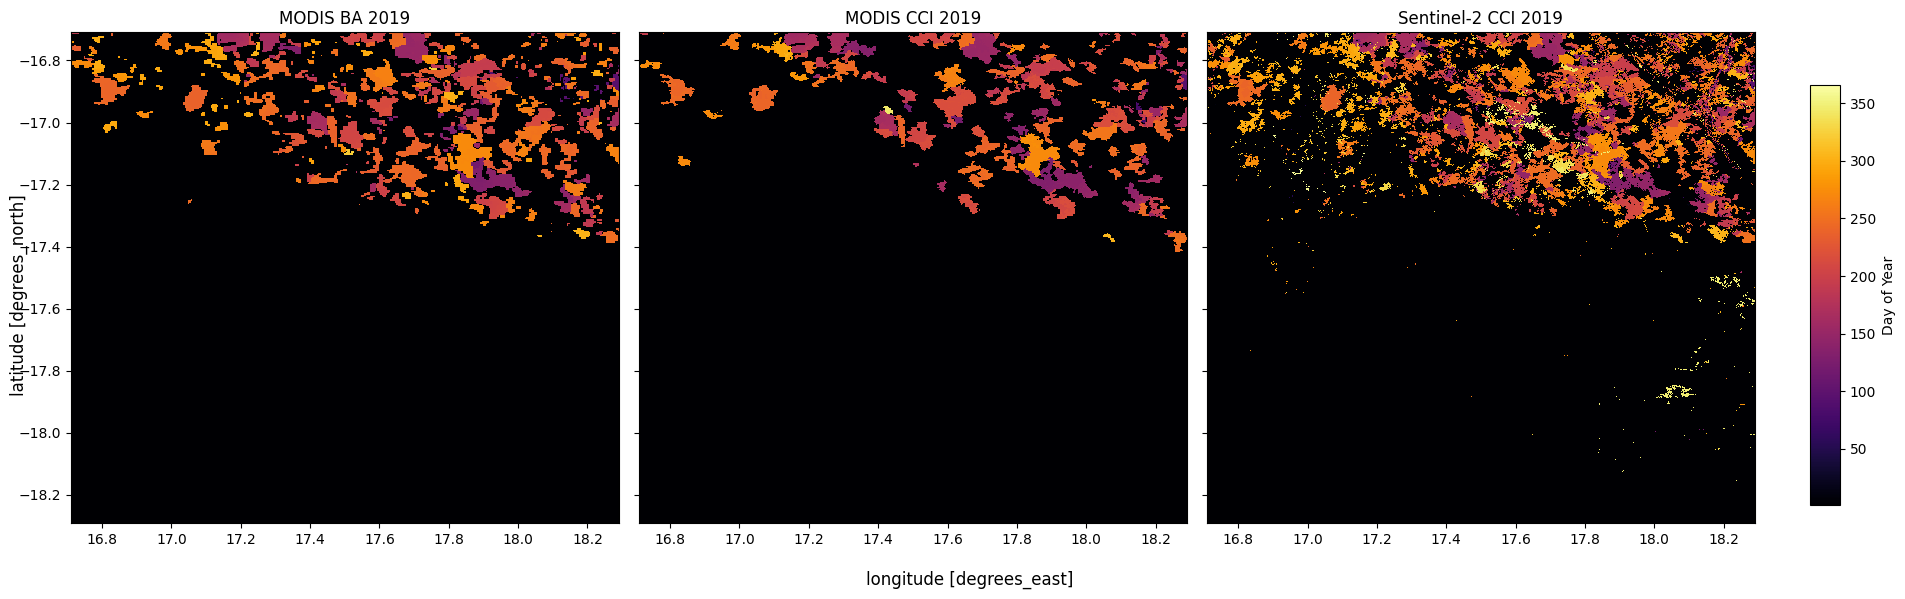

In [299]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

def to_2d(da):
    if 'band' in da.dims:
        da = da.isel(band=0, drop=True)
    return da.squeeze(drop=True)

# 2-D rasters
da1 = to_2d(modis_ba_2019.burn_date_doy)
da2 = to_2d(modis_cci_2019.burn_date_doy)
da3 = to_2d(s2_19.burn_date_doy)

# Shared color scale
norm = Normalize(vmin=1, vmax=366)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True, sharey=True)
ax1, ax2, ax3 = axes

# ---- draw the 3 panels (no per-axis colorbars!) ----
im1 = da1.plot.imshow(ax=ax1, cmap="inferno", norm=norm, add_colorbar=False)
ax1.set_title("MODIS BA 2019")

im2 = da2.plot.imshow(ax=ax2, cmap="inferno", norm=norm, add_colorbar=False)
ax2.set_title("MODIS CCI 2019")

im3 = da3.plot.imshow(ax=ax3, cmap="inferno", norm=norm, add_colorbar=False)
ax3.set_title("Sentinel-2 CCI 2019")

# ---- unify axis labels for all panels ----
for ax in axes:
    ax.set_xlabel("")   # clear auto labels like 'x'
    ax.set_ylabel("")   # clear auto labels like 'y'
fig.supxlabel("longitude [degrees_east]")
fig.supylabel("latitude [degrees_north]")

# ---- one shared colorbar OUTSIDE the grid ----
# Reserve space on the right and place the bar there
cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height] in figure coords
cbar = fig.colorbar(im3, cax=cax)
cbar.set_label("Day of Year")

# Make room for the external colorbar (leave 8% right margin)
plt.tight_layout(rect=[0, 0, 0.90, 1])
plt.show()


In [548]:
burned_area_2019 = modis_ba_2019.burned_mask.astype(int).sum().item(), modis_cci_2019.burned_mask.astype(int).sum().item(), s2_cci_2019.burned_mask.astype(int).sum().item()
burned_area_2016 = modis_ba_2016.burned_mask.astype(int).sum().item(), modis_cci_2016.burned_mask.astype(int).sum().item(), s2_cci_2016.burned_mask.astype(int).sum().item()

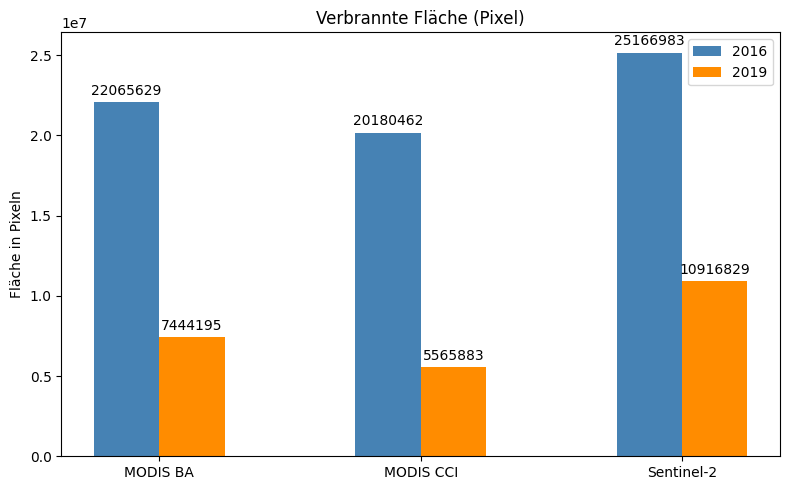

In [587]:
types = ["MODIS BA", "MODIS CCI", "Sentinel-2"]
x = np.arange(len(types))  # the label locations
width = 0.25               # width of each bar

fig, ax = plt.subplots(figsize=(8,5))

bars1 = ax.bar(x - width/2, burned_area_2016, width, label="2016", color="steelblue")
bars2 = ax.bar(x + width/2, burned_area_2019, width, label="2019", color="darkorange")

# Formatting
ax.set_ylabel("Fläche in Pixeln")
ax.set_title("Verbrannte Fläche (Pixel)")
ax.set_xticks(x)
ax.set_xticklabels(types)
ax.legend()

for bars in [bars1, bars2]:
    ax.bar_label(bars, fmt="%.0f", padding=3)

fig.tight_layout()

plt.show()


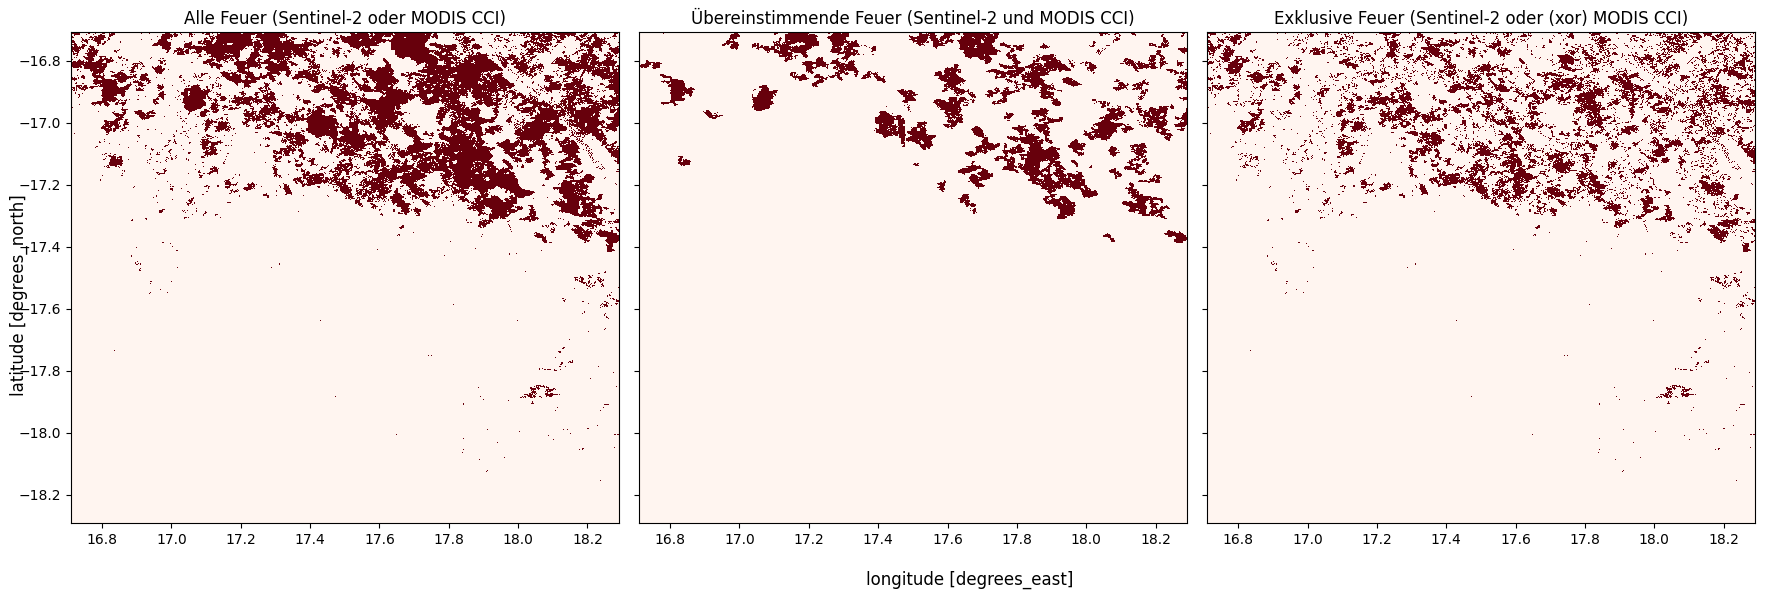

In [303]:
def to_2d(da):
    if 'band' in da.dims:
        da = da.isel(band=0, drop=True)
    return da.squeeze(drop=True)

# 2-D rasters
da1 = to_2d(np.logical_or(s2_cci_2019.burned_mask, modis_cci_2019.burned_mask)[0])
da2 = to_2d(np.logical_and(s2_cci_2019.burned_mask, modis_cci_2019.burned_mask)[0])
da3 = to_2d(np.logical_xor(s2_cci_2019.burned_mask, modis_cci_2019.burned_mask)[0])

# Shared color scale
norm = Normalize(vmin=0, vmax=1)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True, sharey=True)
ax1, ax2, ax3 = axes

# ---- draw the 3 panels (no per-axis colorbars!) ----
im1 = da1.plot.imshow(ax=ax1, cmap="Reds", norm=norm, add_colorbar=False)
ax1.set_title("Alle Feuer (Sentinel-2 oder MODIS CCI)")

im2 = da2.plot.imshow(ax=ax2, cmap="Reds", norm=norm, add_colorbar=False)
ax2.set_title("Übereinstimmende Feuer (Sentinel-2 und MODIS CCI)")

im3 = da3.plot.imshow(ax=ax3, cmap="Reds", norm=norm, add_colorbar=False)
ax3.set_title("Exklusive Feuer (Sentinel-2 oder (xor) MODIS CCI)")

# ---- unify axis labels for all panels ----
for ax in axes:
    ax.set_xlabel("")   # clear auto labels like 'x'
    ax.set_ylabel("")   # clear auto labels like 'y'
fig.supxlabel("longitude [degrees_east]")
fig.supylabel("latitude [degrees_north]")

# ---- one shared colorbar OUTSIDE the grid ----
# Reserve space on the right and place the bar there

# Make room for the external colorbar (leave 8% right margin)
plt.tight_layout(rect=[0, 0, 0.90, 1])
plt.show()


### Finding fires: S2 vs MODIS BA vs MODIS CCI


In [310]:
mba = modis_ba_2019.burned_mask.astype(np.int16)
s2c = s2_cci_2019.burned_mask.astype(np.int16)
mcc = modis_cci_2019.burned_mask.astype(np.int16)

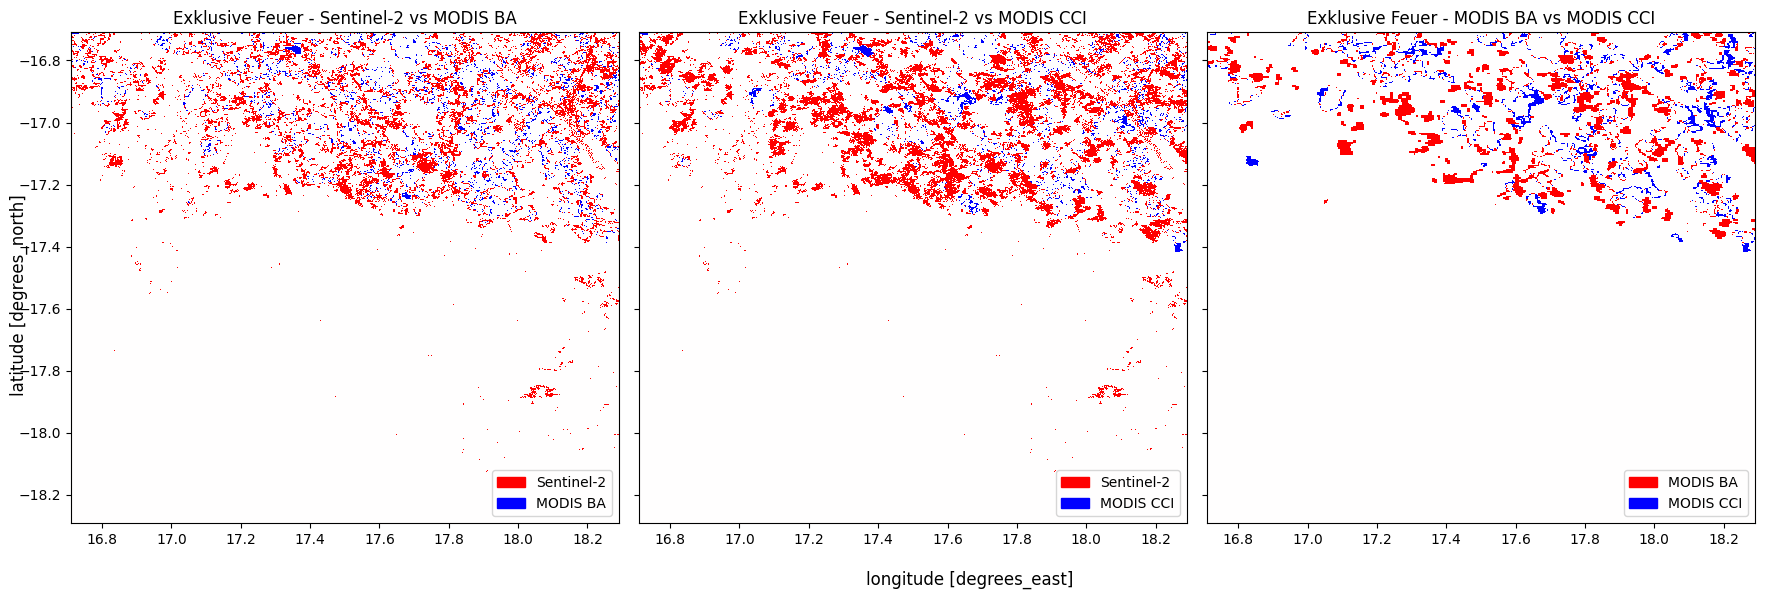

In [311]:

from matplotlib.patches import Patch

def to_2d(da):
    if 'band' in da.dims:
        da = da.isel(band=0, drop=True)
    return da.squeeze(drop=True)

legend = lambda label1, label2:  [
    Patch(facecolor="red", edgecolor="red", label=f"{label1}"),
    Patch(facecolor="blue", edgecolor="blue", label=f"{label2}")
]

# 2-D rasters
da1 = to_2d(s2c-mba)
da2 = to_2d(s2c-mcc)
da3 = to_2d(mba-mcc)

# Shared color scale
norm = Normalize(vmin=-1, vmax=1)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True, sharey=True)
ax1, ax2, ax3 = axes

# ---- draw the 3 panels (no per-axis colorbars!) ----
im1 = da1.plot.imshow(ax=ax1, cmap="bwr", norm=norm, add_colorbar=False)
ax1.set_title("Exklusive Feuer - Sentinel-2 vs MODIS BA")
ax1.legend(handles=legend("Sentinel-2", "MODIS BA"), loc="lower right")

im2 = da2.plot.imshow(ax=ax2, cmap="bwr", norm=norm, add_colorbar=False)
ax2.set_title("Exklusive Feuer - Sentinel-2 vs MODIS CCI")
ax2.legend(handles=legend("Sentinel-2", "MODIS CCI"), loc="lower right")

im3 = da3.plot.imshow(ax=ax3, cmap="bwr", norm=norm, add_colorbar=False)
ax3.set_title("Exklusive Feuer - MODIS BA vs MODIS CCI")
ax3.legend(handles=legend("MODIS BA", "MODIS CCI"), loc="lower right")

# ---- unify axis labels for all panels ----
for ax in axes:
    ax.set_xlabel("")   # clear auto labels like 'x'
    ax.set_ylabel("")   # clear auto labels like 'y'
fig.supxlabel("longitude [degrees_east]")
fig.supylabel("latitude [degrees_north]")

# ---- one shared colorbar OUTSIDE the grid ----
# Reserve space on the right and place the bar there

# Make room for the external colorbar (leave 8% right margin)
plt.tight_layout(rect=[0, 0, 0.90, 1])
plt.show()


## Jaccard Index

#### Comparison for the entire year:

In [314]:
def jaccard_entire_year(dataset1, dataset2):
    ds1 = dataset1.burned_mask.astype(np.int16)
    ds2 = dataset2.burned_mask.astype(np.int16)
    return (((ds1-ds2) == 0).sum() / ds1.size).item()

In [322]:
jc_2016 = jaccard_entire_year(modis_ba_2016, modis_cci_2016), jaccard_entire_year(modis_ba_2016, s2_cci_2016), jaccard_entire_year(modis_cci_2016, s2_cci_2016)

In [323]:
jc_2019 = jaccard_entire_year(modis_ba_2019, modis_cci_2019), jaccard_entire_year(modis_ba_2019, s2_cci_2019), jaccard_entire_year(modis_cci_2019, s2_cci_2019)

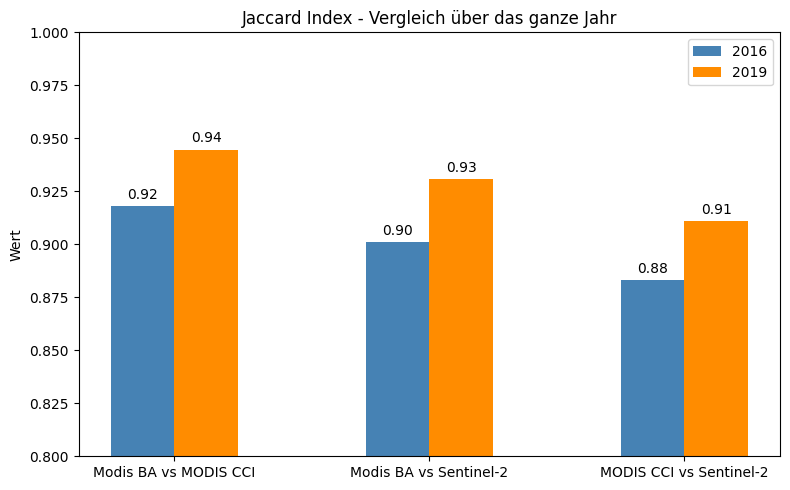

In [588]:
types = ["Modis BA vs MODIS CCI", "Modis BA vs Sentinel-2", "MODIS CCI vs Sentinel-2"]
x = np.arange(len(types))  # the label locations
width = 0.25               # width of each bar

fig, ax = plt.subplots(figsize=(8,5))

bars1 = ax.bar(x - width/2, jc_2016, width, label="2016", color="steelblue")
bars2 = ax.bar(x + width/2, jc_2019, width, label="2019", color="darkorange")

# Formatting
ax.set_ylabel("Wert")
ax.set_title("Jaccard Index - Vergleich über das ganze Jahr")
ax.set_xticks(x)
ax.set_ylim(0.8, 1.0)
ax.set_xticklabels(types)
ax.legend()

for bars in [bars1, bars2]:
    ax.bar_label(bars, fmt="%.2f", padding=3)

fig.tight_layout()

plt.show()


#### By day of year (doy)

In [332]:
def jaccard_by_doy(dataset1, dataset2):
    jaccard_values = []

    total = dataset1.size

    for day in tqdm(range(1, 366)):

        mask1 = (dataset1==day).astype(np.int32)
        mask2 = (dataset2==day).astype(np.int32)

        jaccard_values.append((((mask1-mask2)==0).sum() / total).item())

    return jaccard_values

In [589]:
j_by_doy = jaccard_by_doy(s2_cci_2016.burn_date_doy,modis_ba_2016.burn_date_doy)

100%|██████████| 365/365 [01:12<00:00,  5.02it/s]


/var/folders/qp/6s799t797f17j9t6jsv41rpr0000gn/T/ipykernel_48541/2144948873.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


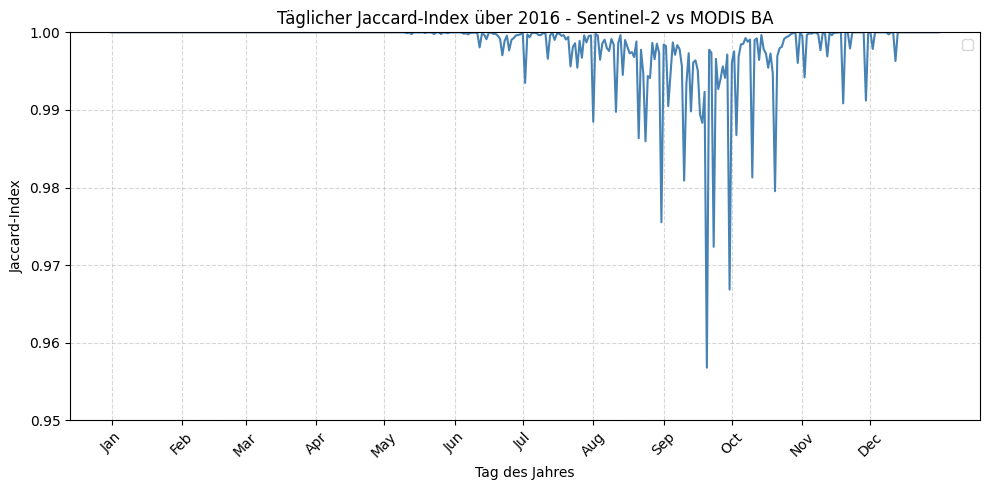

In [590]:
t = list(range(1,366))

plt.figure(figsize=(10,5))
plt.plot(t, j_by_doy, color="steelblue", linewidth=1.5)

plt.xlabel("Tag des Jahres")
plt.ylabel("Jaccard-Index")
plt.title("Täglicher Jaccard-Index über 2016 - Sentinel-2 vs MODIS BA")
plt.ylim(0.95, 1.0)
plt.grid(True, linestyle="--", alpha=0.5)


# months on x-axis
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
plt.xticks(month_starts, list(calendar.month_abbr)[1:], rotation=45)

plt.legend()
plt.tight_layout()
plt.show()


#### By month

In [173]:
def create_doy_by_month(year):
    # pick a year (important for leap years)
    doy_by_month = {}

    for month in range(1, 13):
        days_in_month = calendar.monthrange(year, month)[1]
        doys = []
        for day in range(1, days_in_month + 1):
            date = datetime.date(year, month, day)
            doy = date.timetuple().tm_yday
            doys.append(doy)
        doy_by_month[month] = doys

    return doy_by_month

In [174]:
def jaccard_by_month(dataset1, dataset2):
    doy_by_month = create_doy_by_month(2016)

    jaccard_values = []

    total = dataset1.size

    for month in tqdm(range(1,13)):

        doys = doy_by_month[month]

        mask1 = np.isin(dataset1, doys).astype(np.int32)
        mask2 = np.isin(dataset2, doys).astype(np.int32)

        jaccard_values.append((((mask1-mask2)==0).sum() / total).item())

    return jaccard_values

In [175]:
j_by_month = jaccard_by_month(s2_cci_2016.burn_date_doy,modis_ba_2016.burn_date_doy)

100%|██████████| 12/12 [00:35<00:00,  2.97s/it]


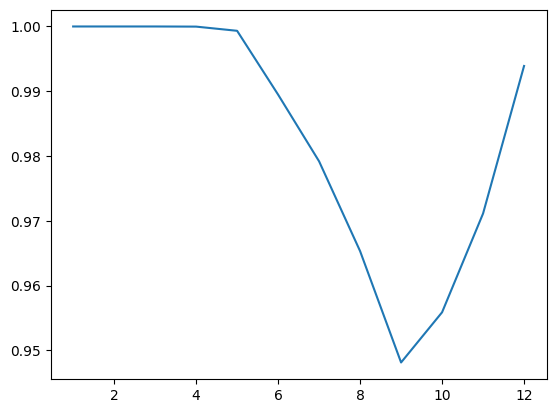

In [177]:
t = list(range(1,13))
plt.plot(t, j_by_month)

## Clustering

In [348]:
fires_mcci = cluster_by_area_and_time(modis_cci_2016)
fires_mcci = fires_mcci.expand_dims("band")
modis_cci_2016 = modis_cci_2016.assign(fire_clusters=fires_mcci)

In [363]:
from matplotlib.colors import hsv_to_rgb

def plot_clusters(da, title,background_id=-1, sat=0.65, val=0.9, figsize=(10,10), draw_edges=False):
    # ---- ensure 2D labels ----
    # If there's a 'band' dim, take band 0; otherwise squeeze singleton dims.
    if 'band' in da.dims:
        da2 = da.isel(band=0, drop=True)
    else:
        da2 = da.squeeze(drop=True)
    labels = np.asarray(da2.values, dtype=np.int64)
    if labels.ndim != 2:
        raise ValueError(f"Expected 2D labels, got shape {labels.shape}")

    H, W = labels.shape

    # ---- color by golden-angle hue ----
    phi = 0.61803398875
    h = (labels * phi) % 1.0
    s = np.full((H, W), sat, dtype=np.float32)
    v = np.full((H, W), val, dtype=np.float32)

    # background = white
    bg = (labels == background_id)
    s[bg] = 0.0
    v[bg] = 1.0

    hsv = np.stack([h.astype(np.float32), s, v], axis=-1)
    rgb = hsv_to_rgb(hsv)

    # optional thin black edges between clusters
    if draw_edges:
        dy = np.zeros_like(labels, dtype=bool)
        dx = np.zeros_like(labels, dtype=bool)
        dy[1:] = labels[1:] != labels[:-1]
        dx[:, 1:] = labels[:, 1:] != labels[:, :-1]
        edges = (dx | dy) & ~bg
        rgb[edges] = 0.0

    # ---- coordinate extent/origin if x/y coords exist ----
    extent = None
    origin = 'upper'
    if 'x' in da2.dims and 'y' in da2.dims:
        xs = da2['x'].values
        ys = da2['y'].values
        extent = [xs.min(), xs.max(), ys.min(), ys.max()]
        # image rows increase downward; flip if y increases upward
        origin = 'lower' if ys[1] > ys[0] else 'upper'

    plt.figure(figsize=figsize)
    plt.imshow(rgb, extent=extent, origin=origin, interpolation='nearest', rasterized=True)
    plt.title(title)
    if extent is not None:
        plt.axis('equal')
        plt.xlabel("longitude [degrees_east]")
        plt.ylabel("latitude [degrees_north]")
    plt.tight_layout()
    plt.show()


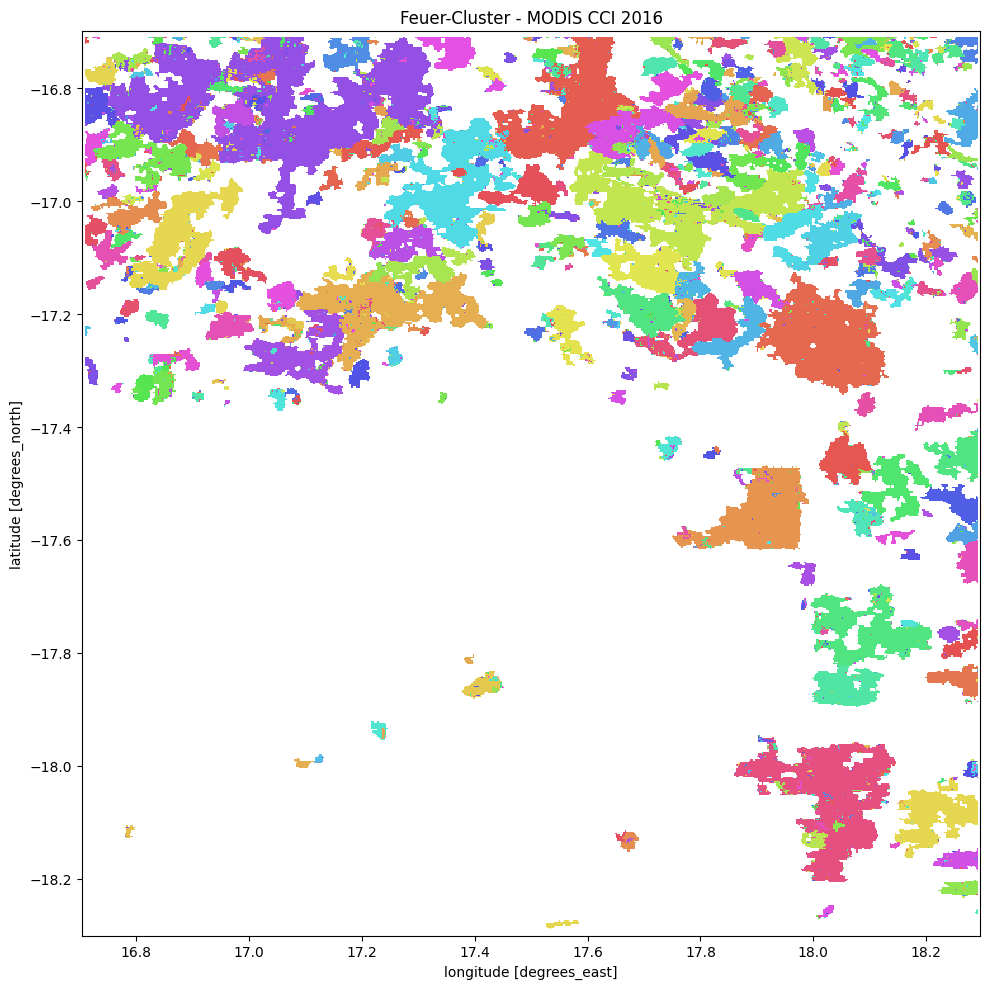

In [370]:
plot_clusters(modis_cci_2016.fire_clusters, "Feuer-Cluster - MODIS CCI 2016")

## About fires

In [ ]:
def compare_fires_majority_overlap(
    dataset1: xr.Dataset,
    dataset2: xr.Dataset,
    time_threshold: int = 5,
    days_in_year: int = 365,
) -> dict:

    c1 = np.asarray(dataset1.fire_clusters)
    c2 = np.asarray(dataset2.fire_clusters)
    d1 = np.asarray(dataset1.burn_date_doy)
    d2 = np.asarray(dataset2.burn_date_doy)

    c2_mask_all = (c2 != -1)
    if np.any(c2_mask_all):
        labels2_all, counts2_all = np.unique(c2[c2_mask_all].astype(np.int64), return_counts=True)
        cluster2_size_map = dict(zip(labels2_all.tolist(), counts2_all.tolist()))
    else:
        cluster2_size_map = {}

    valid = (c1 != -1) & np.isfinite(d1)
    if not np.any(valid):
        return {}

    lbl1 = c1[valid].astype(np.int64, copy=False)
    d1v  = d1[valid].astype(np.int32,  copy=False)
    d2v  = d2[valid].astype(np.int32,  copy=False)
    c2v  = c2[valid].astype(np.int64,  copy=False)

    order = np.argsort(lbl1, kind="mergesort")
    lbl1_sorted = lbl1[order]
    d1_sorted   = d1v[order]
    d2_sorted   = d2v[order]
    c2_sorted   = c2v[order]

    boundaries = np.flatnonzero(np.r_[True, lbl1_sorted[1:] != lbl1_sorted[:-1]])
    boundaries = np.r_[boundaries, lbl1_sorted.size]

    results = {}
    for i in range(len(boundaries) - 1):
        start, end = boundaries[i], boundaries[i + 1]
        fire_id = int(lbl1_sorted[start])

        d1_slice = d1_sorted[start:end]
        d2_slice = d2_sorted[start:end]
        c2_slice = c2_sorted[start:end]

        # Size of this dataset1 cluster (pixel count)
        size1 = end - start

        # First/last in dataset1 (ignore zeros)
        d1_pos = d1_slice[d1_slice > 0]
        if d1_pos.size == 0:
            results[fire_id] = {
                "size1": size1,
                "matched_cluster2_id": -1,
                "overlap_pixels_2": 0,
                "matched_cluster2_size": 0,
                "first_encountered_1": -1,
                "first_encountered_2": -1,
            }
            continue

        first1 = int(d1_pos.min())
        last1  = int(d1_pos.max())

        c2_pos = c2_slice[c2_slice != -1]
        if c2_pos.size:
            labels2, counts2 = np.unique(c2_pos, return_counts=True)
            j = int(np.argmax(counts2))
            matched_c2 = int(labels2[j])
            overlap_pixels_2 = int(counts2[j])
            matched_cluster2_size = int(cluster2_size_map.get(matched_c2, 0))
        else:
            matched_c2 = -1
            overlap_pixels_2 = 0
            matched_cluster2_size = 0

        lo = max(1, first1 - time_threshold)
        hi = min(days_in_year, last1 + time_threshold)
        d2_in_win = d2_slice[(d2_slice > 0) & (d2_slice >= lo) & (d2_slice <= hi)]
        first2 = int(d2_in_win.min()) if d2_in_win.size else -1

        results[fire_id] = {
            "size1": size1,
            "matched_cluster2_id": matched_c2,
            "overlap_pixels_2": overlap_pixels_2,
            "matched_cluster2_size": matched_cluster2_size,
            "first_encountered_1": first1,
            "first_encountered_2": first2,
        }

    return results


In [60]:
results = compare_fires_majority_overlap(s2_cci_2016, modis_ba_2016)

In [372]:
comp_s2_mba_16 = compare_fires_majority_overlap(s2_cci_2016, modis_ba_2016)
comp_s2_mcci_16 = compare_fires_majority_overlap(s2_cci_2016, modis_cci_2016)
comp_mba_mcci_16 = compare_fires_majority_overlap(modis_ba_2016, modis_cci_2016)
comp_s2_mba_19 = compare_fires_majority_overlap(s2_cci_2019, modis_ba_2019)
comp_s2_mcci_19 = compare_fires_majority_overlap(s2_cci_2019, modis_cci_2019)
comp_mba_mcci_19 = compare_fires_majority_overlap(modis_ba_2019, modis_cci_2019)

In [432]:
comp_mba_s2_16 = compare_fires_majority_overlap(modis_ba_2016, s2_cci_2016)
comp_mcci_s2_16 = compare_fires_majority_overlap(modis_cci_2016, s2_cci_2016)
comp_mcci_mba_16 = compare_fires_majority_overlap(modis_cci_2016, modis_ba_2016)
comp_mba_s2_19 = compare_fires_majority_overlap(modis_ba_2019, s2_cci_2019)
comp_mcci_s2_19 = compare_fires_majority_overlap(modis_cci_2019, s2_cci_2019)
comp_mcci_mba_19 = compare_fires_majority_overlap(modis_cci_2019, modis_ba_2019)

/var/folders/qp/6s799t797f17j9t6jsv41rpr0000gn/T/ipykernel_48541/423166970.py:40: RuntimeWarning: invalid value encountered in cast
  d2v  = d2[valid].astype(np.int32,  copy=False)


In [392]:
def get_sizes_of_clusters(clusters: xr.DataArray) -> np.array:
    labels = clusters.values.ravel()
    return np.bincount(labels[labels>=0].astype(np.int64))


In [393]:
sizes_ba_16 = get_sizes_of_clusters(modis_ba_2016.fire_clusters)
sizes_ba_19 = get_sizes_of_clusters(modis_ba_2019.fire_clusters)
sizes_mcci_16 = get_sizes_of_clusters(modis_cci_2016.fire_clusters)
sizes_mcci_19 = get_sizes_of_clusters(modis_cci_2019.fire_clusters)
sizes_s2_16 = get_sizes_of_clusters(s2_cci_2016.fire_clusters)
sizes_s2_19 = get_sizes_of_clusters(s2_cci_2019.fire_clusters)

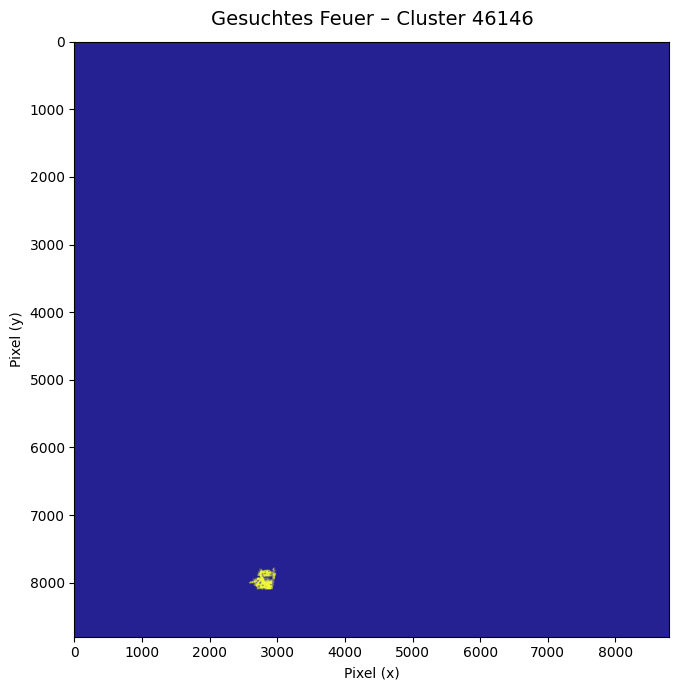

In [424]:
import matplotlib.pyplot as plt
import numpy as np

cluster_id = 46146
mask = (s2_cci_2016.fire_clusters[0] == cluster_id)

ys, xs = np.where(mask)

fig, ax = plt.subplots(figsize=(7, 7))

# Hintergrund leicht grau
background = np.ones_like(mask, dtype=float) * np.nan
background[~mask] = 1
ax.imshow(background, cmap="Greys", alpha=0.2)

# Feuer farbig
ax.imshow(mask, cmap="plasma", alpha=0.9)

# Titel und Achsen
ax.set_title(f"Gesuchtes Feuer – Cluster {cluster_id}", fontsize=14, pad=12)
ax.set_xlabel("Pixel (x)")
ax.set_ylabel("Pixel (y)")

ax.grid(False)

plt.tight_layout()
plt.show()


In [126]:
np.unique(s2_cci_2016.where(s2_cci_2016.fire_clusters[0] == 46146).burn_date_doy)

array([346.,  nan], dtype=float32)

Das größte Feuer (46146) das von s2 gefunden worden ist, von Modis BA aber nicht, hat eine Fläche von 58851 pixeln (20m). Man kann auf den Bildern gut erkennen, welches Feuer das ist und das Modis dieses auch nicht gefunden hat. 

In [140]:
arr1, arr2 = np.array(match), np.array(no_match)

def summary(arr):
    return {
        "count": arr.size,
        "min": arr.min(),
        "max": arr.max(),
        "mean": arr.mean(),
        "median": np.median(arr),
        "std": arr.std(),
        "q25": np.percentile(arr, 25),
        "q75": np.percentile(arr, 75),
    }

print("Dataset 1:", summary(arr1))
print("Dataset 2:", summary(arr2))


Dataset 1: {'count': 12150, 'min': np.int64(1), 'max': np.int64(1424810), 'mean': np.float64(1914.605596707819), 'median': np.float64(6.0), 'std': np.float64(22150.163242022212), 'q25': np.float64(1.0), 'q75': np.float64(43.0)}
Dataset 2: {'count': 40317, 'min': np.int64(1), 'max': np.int64(58851), 'mean': np.float64(47.23875784408562), 'median': np.float64(5.0), 'std': np.float64(390.46009423854326), 'q25': np.float64(1.0), 'q75': np.float64(18.0)}


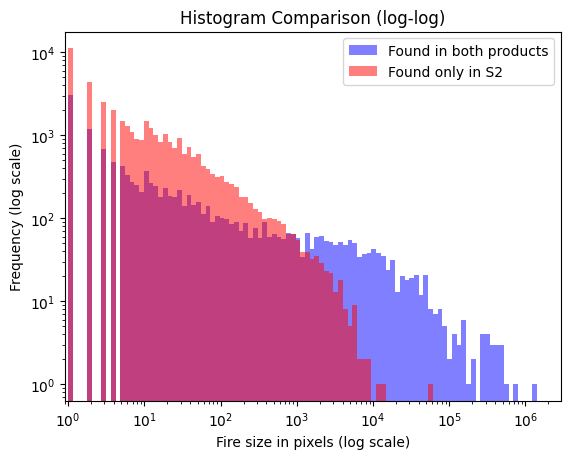

In [190]:
min_val = min(arr1.min(), arr2.min())
bins = np.logspace(np.log10(min_val), np.log10(max(arr1.max(), arr2.max())), 100)

plt.hist(arr1, bins=bins, alpha=0.5, label="Found in both products", color="blue")
plt.hist(arr2, bins=bins, alpha=0.5, label="Found only in S2", color="red")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.xlim(left=0.9)
plt.margins(x=0.01)   
plt.xlabel("Fire size in pixels (log scale)")
plt.ylabel("Frequency (log scale)")
plt.title("Histogram Comparison (log-log)")
plt.show()


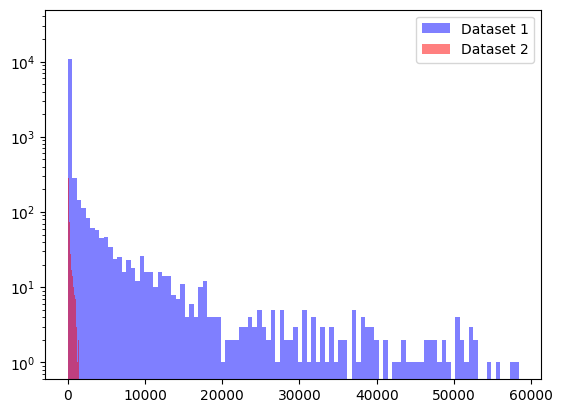

In [156]:
cap1 = np.percentile(arr1, 99.5)
cap2 = np.percentile(arr2, 99.5)

plt.hist(arr1[arr1 < cap1], bins=100, alpha=0.5, label="Dataset 1", color="blue")
plt.hist(arr2[arr2 < cap2], bins=100, alpha=0.5, label="Dataset 2", color="red")
plt.yscale("log")
plt.legend()
plt.show()


In [ ]:
match = []
no_match = []


for fire in results.keys():
    if results[fire]['matched_cluster2_id'] != -1:
        match.append(results[fire]['size1'].item())
    else:
        no_match.append(results[fire]['size1'].item())

arr1, arr2 = np.array(match), np.array(no_match)

In [ ]:
comp_s2_mba_16 = compare_fires_majority_overlap(s2_cci_2016, modis_ba_2016)
comp_s2_mcci_16 = compare_fires_majority_overlap(s2_cci_2016, modis_cci_2016)
comp_mba_mcci_16 = compare_fires_majority_overlap(modis_ba_2016, modis_cci_2016)
comp_s2_mba_19 = compare_fires_majority_overlap(s2_cci_2019, modis_ba_2019)
comp_s2_mcci_19 = compare_fires_majority_overlap(s2_cci_2019, modis_cci_2019)
comp_mba_mcci_19 = compare_fires_majority_overlap(modis_ba_2019, modis_cci_2019)

In [ ]:
comp_mba_s2_16 = compare_fires_majority_overlap(modis_ba_2016, s2_cci_2016)
comp_mcci_s2_16 = compare_fires_majority_overlap(modis_cci_2016, s2_cci_2016)
comp_mcci_mba_16 = compare_fires_majority_overlap(modis_cci_2016, modis_ba_2016)
comp_mba_s2_19 = compare_fires_majority_overlap(modis_ba_2019, s2_cci_2019)
comp_mcci_s2_19 = compare_fires_majority_overlap(modis_cci_2019, s2_cci_2019)
comp_mcci_mba_19 = compare_fires_majority_overlap(modis_cci_2019, modis_ba_2019)

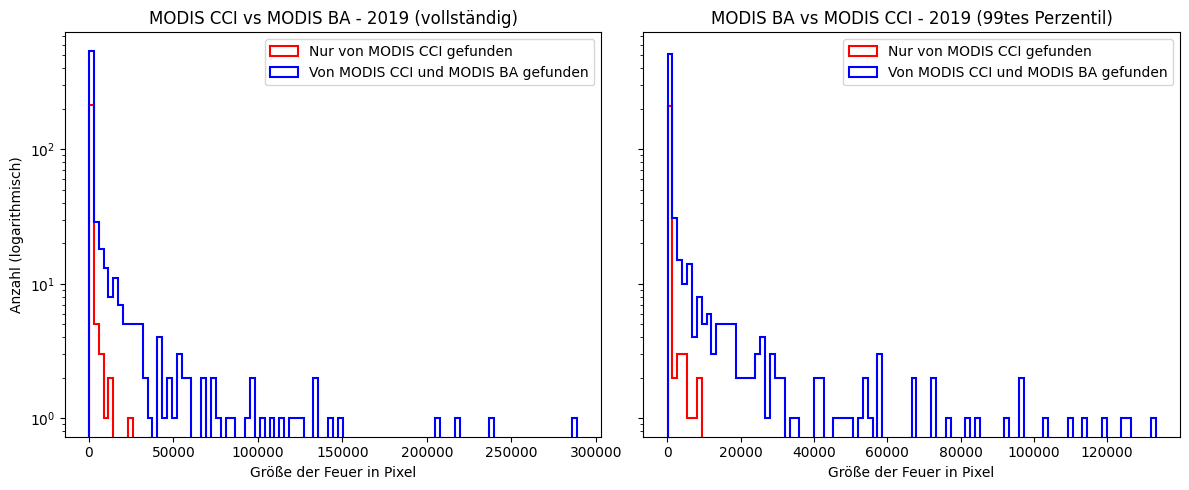

In [ ]:
results = comp_s2_mba_16
prod_1 = "Sentinel-2 CCI"
#prod_1 = "MODIS BA"
#prod_1 = "MODIS CCI"
#prod_2 = "Sentinel-2 CCI"
prod_2 = "MODIS BA"
#prod_2 = "MODIS CCI"
year = 2016
#year = 2019
filename = f"size_comparison_{'_'.join([prod_1, prod_2, str(year)])}.png"

match = []
no_match = []

for fire in results.keys():
    if results[fire]['matched_cluster2_id'] != -1:
        match.append(results[fire]['size1'].item())
    else:
        no_match.append(results[fire]['size1'].item())

arr1, arr2 = np.array(match), np.array(no_match)

cap1 = np.percentile(arr1, 99) # match
cap2 = np.percentile(arr2, 99) # no_match

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

ax1.hist([arr1, arr2],
         bins=100,
         label=[f"Von {prod_1} und {prod_2} gefunden", f"Nur von {prod_1} gefunden"],
         color=["blue", "red"],
         histtype="step", linewidth=1.5)
ax1.set_xlabel("Größe der Feuer in Pixel")
ax1.set_ylabel("Anzahl (logarithmisch)")
ax1.set_title(f"{prod_1} vs {prod_2} - {year} (vollständig)")
ax1.set_yscale("log")
ax1.legend()

ax2.hist([arr1[arr1 <= cap1], arr2[arr2 <= cap2]],
         bins=100,
         label=[f"Von {prod_1} und {prod_2} gefunden", f"Nur von {prod_1} gefunden"],
         color=["blue", "red"],
         histtype="step", linewidth=1.5)
ax2.set_xlabel("Größe der Feuer in Pixel")
ax2.set_title(f"{prod_2} vs {prod_1} - {year} (99tes Perzentil)")
ax2.set_yscale("log")
ax2.legend()

plt.tight_layout()
plt.savefig(Path(f"/Volumes/Crucial 2tb/final_plots/Fire_size/{filename}"))


- Wenn man sich alle Daten anschaut, sieht man recht wenig, weil es große Ausreißer gibt. 
- Man kann aber gut sehen, dass die Feuer die MODIS BA nicht enteckt hat nur bis zu einer bestimmten Größe gehen
- Es gibt in der vollständigen Ansicht aber auch da einen Ausreißer (roter Punkt) -> Dieser ist ein ziemlich großes Feuer, was S2 erkannt hat, MODIS (BA und CCI) nicht. Siehe Darstellungen oben. 
- Die meisten Feuer (4x mehr) wurden nur von S2 gefunden, dies sieht hier zwar anders aus, allerdings liegt das an der logarithmischen y-Achse. Es gibt sehr viele kleine Feuer. 
- Ohne diese seltsamen Ausreißer von großen Feuern gibt es kaum Feuer die größer sind als 825 pixel, welche noch undetektiert bleiben von MODIS BA. Feuer die kleiner als 368 pixel sind, wurden in keinem Fall von MODIS BA gefunden. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def detection_curve_with_thresholds(
    s2_labels, mb_labels,
    pixel_size_m=20.0,
    n_bins=25,                    
    min_overlap_pixels=1,
    match_strategy="best",
    targets=(0.1, 0.5, 0.9),     
    enforce_monotonic=True,      
    title="MODIS BA-Erkennungswahrscheinlichkeit vs. S2-Feuergröße - 2019"
):
    try:
        import xarray as xr
        s2 = np.asarray(s2_labels.data).squeeze() if isinstance(s2_labels, xr.DataArray) else np.asarray(s2_labels).squeeze()
        mb = np.asarray(mb_labels.data).squeeze() if isinstance(mb_labels, xr.DataArray) else np.asarray(mb_labels).squeeze()
    except Exception:
        s2, mb = np.asarray(s2_labels).squeeze(), np.asarray(mb_labels).squeeze()

    if s2.shape != mb.shape:
        raise ValueError(f"Shape mismatch {s2.shape} vs {mb.shape}")

    # --- Clustergrößen (Pixel) ---
    def cluster_sizes(labels):
        shifted = labels + 1
        counts = np.bincount(shifted.ravel())
        return counts[1:]

    s2_sizes_pix = cluster_sizes(s2)
    ha_per_pixel = (pixel_size_m**2)/10_000.0
    s2_sizes_all = s2_sizes_pix * ha_per_pixel

    # --- Overlaps -> gematchte S2-IDs ---
    mask = (s2 >= 0) & (mb >= 0)
    s2v, mbv = s2[mask].ravel(), mb[mask].ravel()
    s2_ids = mb_ids = overlaps = np.array([], dtype=int)
    if len(s2v):
        max_mb = int(mbv.max())
        key = s2v.astype(np.int64)*(max_mb+1) + mbv.astype(np.int64)
        uniq, cnt = np.unique(key, return_counts=True)
        s2_ids = (uniq // (max_mb+1)).astype(int)
        mb_ids = (uniq %  (max_mb+1)).astype(int)
        sel = cnt >= int(min_overlap_pixels)
        s2_ids, mb_ids = s2_ids[sel], mb_ids[sel]

    if match_strategy == "best" and len(s2_ids):
        # best-overlap je S2
        # (overlaps werden hier nicht mehr benötigt)
        pass

    s2_sizes_matched = (s2_sizes_pix[s2_ids] * ha_per_pixel) if len(s2_ids) else np.array([])

    # --- Log-Bins & Erkennungsrate ---
    x = s2_sizes_all[s2_sizes_all > 0]
    edges = np.logspace(np.log10(x.min()), np.log10(x.max()), n_bins+1)
    mids = np.sqrt(edges[:-1] * edges[1:])

    total, _   = np.histogram(s2_sizes_all,    bins=edges)
    detect, _  = np.histogram(s2_sizes_matched, bins=edges)
    n = total.clip(min=1)
    p = detect / n

    if enforce_monotonic:
        p = np.maximum.accumulate(p)

    z = 1.96
    center = (p + z**2/(2*n)) / (1 + z**2/n)
    half   = z*np.sqrt((p*(1-p)/n) + (z**2/(4*n**2))) / (1 + z**2/n)
    lo, hi = np.clip(center - half, 0, 1), np.clip(center + half, 0, 1)

    # --- Thresholds via Interpolation (p vs. size) ---
    # p kann flache Abschnitte haben -> für Interp eindeutige p-Werte nehmen
    pu, idx = np.unique(p, return_index=True)
    mids_u = mids[idx]
    thresholds = {}
    for t in targets:
        if np.isnan(pu).all() or t < pu.min() or t > pu.max():
            thresholds[t] = np.nan
        else:
            logx = np.interp(t, pu, np.log10(mids_u))
            thresholds[t] = 10**logx

    # --- Plot ---
    plt.figure(figsize=(7,5))
    plt.semilogx(mids, p, marker='o', lw=1.5, label='Erkennungsrate (MODIS BA | S2-Größe)')
    plt.fill_between(mids, lo, hi, alpha=0.2, label='95% CI')

    # Linien + Labels
    for t in targets:
        th = thresholds[t]
        plt.axhline(t, ls='--', lw=1)
        if np.isfinite(th):
            plt.axvline(th, ls='--', lw=1)
            plt.text(th, t+0.02, f"{t*100:.0f}% @ ~{th:.1f} ha", ha='left', va='bottom')

    plt.ylim(-0.02, 1.02)
    plt.xlabel("S2-Feuergröße (ha, log)")
    plt.ylabel("Erkennungswahrscheinlichkeit MODIS BA")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {"mids": mids, "p": p, "ci_lo": lo, "ci_hi": hi, "thresholds": thresholds}


/var/folders/qp/6s799t797f17j9t6jsv41rpr0000gn/T/ipykernel_48541/548305497.py:72: RuntimeWarning: invalid value encountered in sqrt
  half   = z*np.sqrt((p*(1-p)/n) + (z**2/(4*n**2))) / (1 + z**2/n)


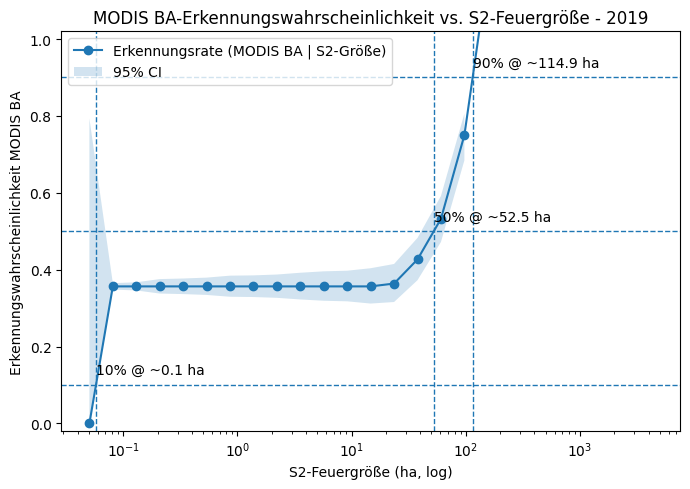

In [499]:
out_mba_2019 = detection_curve_with_thresholds(
    s2_cci_2019.fire_clusters,
    modis_ba_2019.fire_clusters, targets=(0.1, 0.5, 0.9))

## Wann wurden die Feuer gefunden?


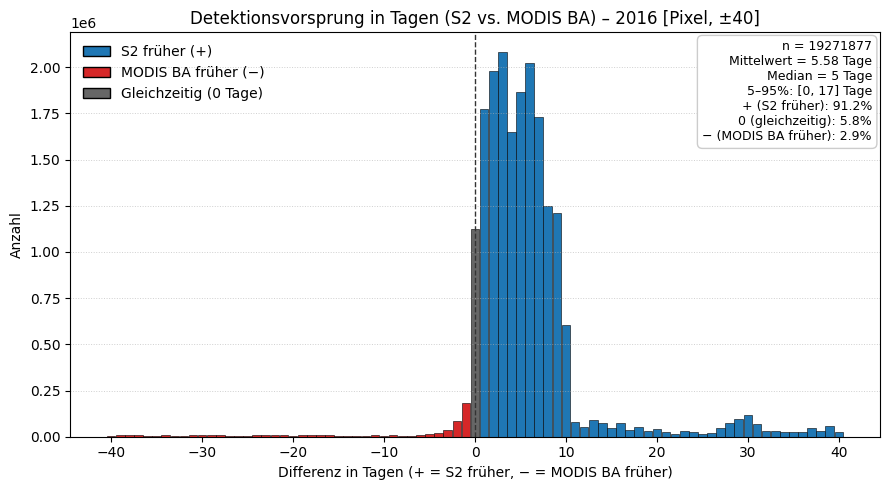

In [597]:
plot_day_deltas_pixel(
    doy1=modis_ba_2016.burn_date_doy,
    doy2=s2_cci_2016.burn_date_doy,
    product1_name="MODIS BA",
    product2_name="S2",
    year=2016,
    window_days=40,
    normalize=False
)


In [406]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_day_deltas(comparison: dict,
                       product1_name: str = "Produkt 1",
                       product2_name: str = "Produkt 2",
                       year: int = 2016,
                       clip: int | None = None,
                       normalize: bool = False,
                       yscale: str = "linear"):
    """
    Plottet die Differenz in Tagen zwischen zwei Satellitenprodukten.
    
    product1_name = Referenz (Delta negativ heißt: Produkt1 früher)
    product2_name = Vergleich (Delta positiv heißt: Produkt2 früher)
    """

    # --- Daten sammeln ---
    deltas = []
    for res in comparison.values():
        if res.get("matched_cluster2_id", -1) == -1:
            continue
        d1 = res.get("first_encountered_1", 0)
        d2 = res.get("first_encountered_2", 0)
        if d1 > 0 and d2 > 0:
            deltas.append(int(round(d2 - d1)))

    if not deltas:
        print("Keine vergleichbaren Detektionen gefunden.")
        return

    deltas = np.asarray(deltas, dtype=int)
    if clip is not None:
        deltas = np.clip(deltas, -clip, clip)

    lo, hi = deltas.min(), deltas.max()
    bins = np.arange(lo - 0.5, hi + 1.5, 1)
    centers = np.arange(lo, hi + 1, 1)

    counts, _ = np.histogram(deltas, bins=bins)
    total = counts.sum()
    values = (counts / total * 100.0) if normalize else counts

    colors = np.where(centers < 0, "tab:red",
             np.where(centers > 0, "tab:blue", "0.4"))

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(centers, values, width=0.95, align="center",
           color=colors, edgecolor="black", linewidth=0.4)

    ax.axvline(0, color="0.2", ls="--", lw=1)
    ax.set_xlabel(f"Differenz in Tagen (+ = {product2_name} früher, − = {product1_name} früher)")
    ax.set_ylabel("Prozent (%)" if normalize else "Anzahl")
    ax.set_title(f"Detektionsvorsprung in Tagen ({product2_name} vs. {product1_name}) - {year}")
    ax.set_yscale(yscale)
    ax.grid(True, axis="y", linestyle=":", linewidth=0.7, alpha=0.6)

    # Legende
    legend_items = [
        Patch(facecolor="tab:blue", edgecolor="black", label=f"{product2_name} früher (+)"),
        Patch(facecolor="tab:red",  edgecolor="black", label=f"{product1_name} früher (−)"),
        Patch(facecolor="0.4",      edgecolor="black", label="Gleichzeitig (0 Tage)")
    ]
    ax.legend(handles=legend_items, frameon=False, loc="upper left")

    # Statistik
    pct_pos = (deltas > 0).mean() * 100
    pct_neg = (deltas < 0).mean() * 100
    pct_zero = (deltas == 0).mean() * 100
    mean = deltas.mean()
    median = int(np.median(deltas))
    p5, p95 = np.percentile(deltas, [5, 95]).astype(int)

    text = (f"n = {total}\n"
            f"Mittelwert = {mean:.2f} Tage\n"
            f"Median = {median} Tage\n"
            f"5–95%: [{p5}, {p95}] Tage\n"
            f"+ ({product2_name} früher): {pct_pos:.1f}%\n"
            f"0 (gleichzeitig): {pct_zero:.1f}%\n"
            f"− ({product1_name} früher): {pct_neg:.1f}%")
    ax.text(0.99, 0.98, text, transform=ax.transAxes,
            va="top", ha="right",
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="0.8"),
            fontsize=9)

    if hi - lo <= 20:
        ax.set_xticks(centers)
    else:
        ax.set_xticks(np.linspace(lo, hi, 9, dtype=int))

    plt.tight_layout()
    plt.show()


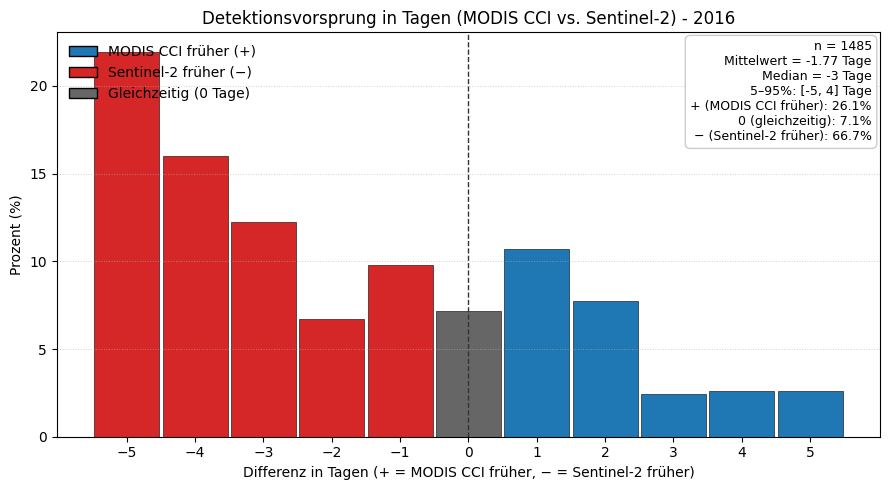

In [412]:
plot_day_deltas(comp_s2_mcci_16, product1_name="Sentinel-2", product2_name="MODIS CCI", year=2016, clip=30, normalize=True, yscale="linear")

In [540]:
out_mba_2019['thresholds']

{0.1: np.float64(0.057840739279229926),
 0.5: np.float64(52.49414656681529),
 0.9: np.float64(114.94331679273937)}

In [541]:
out_mba_2016['thresholds']

{0.1: np.float64(0.06913497211476198),
 0.5: np.float64(18.68869583280527),
 0.9: np.float64(86.51681366005282)}

In [542]:
out_mcci_2016['thresholds']

{0.1: np.float64(0.06942316048558712),
 0.5: np.float64(10.223171925604118),
 0.9: np.float64(38.3584510913697)}

In [543]:
out_mcci_2019['thresholds']

{0.1: np.float64(0.058842624015208476),
 0.5: np.float64(39.13126884838217),
 0.9: np.float64(91.18485119871696)}

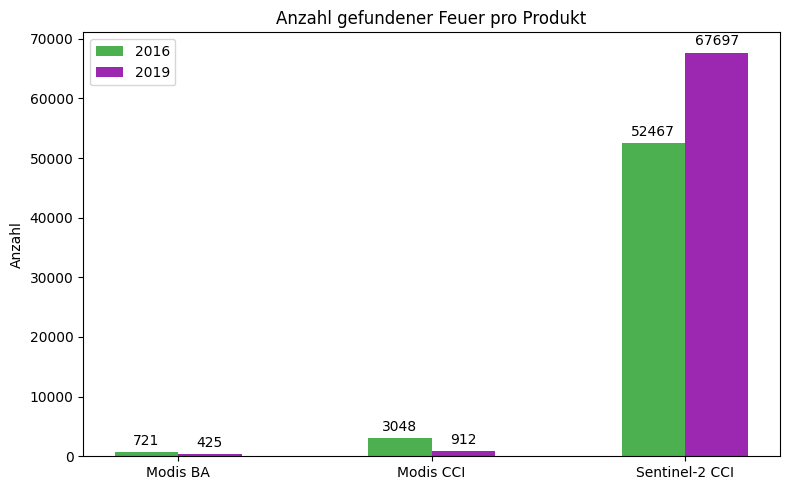

In [567]:
types = ["Modis BA", "Modis CCI", "Sentinel-2 CCI"]
x = np.arange(len(types))  # the label locations
width = 0.25               # width of each bar

fig, ax = plt.subplots(figsize=(8,5))

# Using different colors - forest green and burgundy
bars1 = ax.bar(x - width/2, amount_of_fires_2016, width, label="2016", color="#4CAF50")  # forest green
bars2 = ax.bar(x + width/2, amount_of_fires_2019, width, label="2019", color="#9C27B0")  # purple

# Formatting
ax.set_ylabel("Anzahl")
ax.set_title("Anzahl gefundener Feuer pro Produkt")
ax.set_xticks(x)
ax.set_xticklabels(types)
ax.legend()

for bars in [bars1, bars2]:
    ax.bar_label(bars, fmt="%.0f", padding=3)

fig.tight_layout()

plt.show()
